## Import Packages

In [44]:
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
import scipy.optimize as optimize
from scipy.optimize import curve_fit
from scipy.optimize import fsolve, bisect
import pandas as pd

## NaCl Data

In [51]:
# loading NaCl specific conductivity data
specific_data = pd.read_csv("./Data/NaCl_cleaned.csv")
salt_conc = specific_data["NaCl conc"]
cond_exp = specific_data["NaCl cond cal"]

# number of data points
ndata = len(cond_exp)

## Constants

In [299]:
Avogadros_num = 6.022*10**23 # Avogadro's number
k_B = 1.381 * 10**(-23) # Boltzman constant
T = 298.15 # temperature
charge = 1.602 * 10**(-19) # electronic charge

# diffusion coefficients at infinite dilution
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1

# measuring voltage
voltage = 25 * 10**(-3)
distance = 9 * 10**(-6)

# hard sphere diameters
sigma_Cl = 181 * 10**(-12)
sigma_Na = 102 * 10**(-12)

# solvent viscosity
eta = 0.89 * 10**(-3)

# electric field
E_field = voltage/distance

# other constants
epsilon = 78.4
epsilon_0 = 8.854 * 10**(-12)

diff_coeff = [Diff_Na, Diff_Cl] # diffusion coefficients of Na, and Cl, respectively
valency = [z_Na, z_Cl] # valencies of Na, and Cl, respectively

In [291]:
theta = [sigma_Na, sigma_Cl]

# scaling between 0 and 1
min_theta = min(theta)
max_theta = max(theta)

# apply the scaling formula
scaled_theta = [(value - min_theta) / (max_theta - min_theta) for value in theta]

print("Scaled theta:", scaled_theta)

Scaled theta: [0.0, 1.0]


## Conductivity Model

In [292]:
# MSA transport model function for specific conductivity calculation
def double_conductivity_model(theta, x):
    """Calculates specific conductivity of multi-ion salt solution

    Argument:
        salt_conc = concentration of salt from data in mM
        valency: list of the valency of ions (cations listed before anions in decreasing order)
        diameters: list of the corresponding hard sphere diameter of ions in m
        diff_coeff: list of the corresponding diffusion coefficient at infinite dilution of ions in m^2/s

    Returns:
        all_cond_calc_con: specific conductivity in micro.S/cm"""

    # diameter of ions
    diameters = [(sigma_Cl - sigma_Na)*theta[d] + sigma_Na for d in range(len(theta))]
    
    # converting molar concentrations to number density
    number_density_salt = [x[i]*Avogadros_num for i in range(ndata)]
    
    # components list
    components = ["cation", "anion"]
    
    # number of species
    n_species = len(components)
    
    # species charge
    ion_charge = [valency[i]*charge for i in range(len(valency))]
    
    # evaluating number density of individual species
    number_density_cat = number_density_salt
    number_density_an = [valency[0]*number_density_salt[i] for i in range(ndata)]
    
    # conductivity
    all_cond_calc = np.zeros(ndata)
    
    # for mixture concentration (row) in data
    for n in range(ndata):
        # number density of species
        n_cat = number_density_cat[n]
        n_an =  number_density_an[n]
        number_density = [n_cat, n_an]
        
        # evaluating omega and mew for all species
        omega = np.zeros(n_species)
        mew = np.zeros(n_species)
        for a in range(n_species):
            omega[a] = diff_coeff[a]/(k_B*T) 
            mew[a] = number_density[a]*ion_charge[a]**2/sum(number_density[j]*ion_charge[j]**2 for j in range(n_species))
    
        # evaluating kappa from equation (5)
        kappa = math.sqrt(sum(number_density[l]*ion_charge[l]**2/(epsilon*epsilon_0*k_B*T) for l in range(n_species)))
        
        # evaluating the mean mobility, omega_bar from equation (7)
        omega_bar = sum(mew[j]*omega[j] for j in range(n_species))
    
        # evaluating transport number for all species from equation (8)
        transport_num = np.zeros(n_species)
        for j in range(n_species):
            transport_num[j] = mew[j]*omega[j]/omega_bar
        
        # ksi matrix
        ksi = np.zeros((n_species, n_species))
    
        # conductivity of species from equation (1)
        cond_species = np.zeros(n_species)
    
        # calculating delta from equation (21)
        delta = 1 - ((math.pi/6)*sum(number_density[k]*diameters[k]**3 for k in range(n_species)))
    
        # writing a function that evaluates equation (18)
        def func_gamma(gamma):
            """
            Evaluates residual of equation (18)
    
            Arguments:
                gamma
    
            Returns:
                Residual of the equation
            """
            # calculating capital omega from equation (20)
            capital_omega = 1 + ((math.pi/(2*delta))*sum(number_density[k]*diameters[k]**3/(1 + gamma*diameters[k]) for k in range(n_species)))
    
            # calculating Pn from equation (19)
            P_n = (1/capital_omega)*sum(number_density[k]*diameters[k]*valency[k]/(1 + gamma*diameters[k]) for k in range(n_species))
            
            return(4*epsilon_0*gamma**2 - ((charge**2)/(epsilon*k_B*T))*
                   sum(number_density[l]*((valency[l] - (math.pi*P_n*diameters[l]**2/(2*delta)))/(1 + gamma*diameters[l]))**2 for l in range(n_species)))
    
        # finding gamma, the root of equation (18)
        gamma = bisect(func_gamma, 0, 0.5*kappa)
    
        # re-evaluating capital_omega, P_n and nu
        capital_omega = 1 + ((math.pi/(2*delta))*sum(number_density[k]*diameters[k]**3/(1 + gamma*diameters[k]) for k in range(n_species)))
        P_n = (1/capital_omega)*sum(number_density[k]*diameters[k]*valency[k]/(1 + gamma*diameters[k]) for k in range(n_species))
    
        # nu values for all species from equation (17)
        nu = np.zeros(n_species)
        for k in range(n_species):
            nu[k] = (gamma*valency[k]/(1 + gamma*diameters[k])) + (math.pi/(2*delta))*(P_n*diameters[k]/(1 + gamma*diameters[k]))
    
        # evaluating q and N for all species from equation (9) and (11) respectively
        q = np.zeros(n_species)
        N = np.zeros(n_species)
        alpha_scaled = np.zeros(n_species)
    
        # function that evaluates equation (12)
        def func_alpha(alpha_scaled):
            """ 
            Evaluates residuals of equation 12
    
            Arguments:
                alpha_scaled = alpha/omega_bar
    
            Returns:
                residual of the equation
            """
            return((alpha_scaled)*sum(transport_num[k]/((omega[k]/omega_bar)**2 - (alpha_scaled)**2) for k in range(n_species)))
        
        # since alpha is scaled by omega_bar, the bounds (omega), need to be scaled by same factor
        omega_scaled = np.zeros(n_species)
        for k in range(n_species):
            omega_scaled[k] = omega[k]/omega_bar
    
        # updating the values of alpha_scaled
        for p in range(n_species):
            if p == 0:
                alpha_scaled[p] = bisect(func_alpha, 0, 0.991*omega_scaled[p])
            else:
                alpha_scaled[p] = bisect(func_alpha, 1.001*omega_scaled[p-1], 0.991*omega_scaled[p])
    
        # rescaling alpha_scaled back to alpha
        alphas = [alpha_scaled[p]*omega_bar for p in range(n_species)]
    
        # updating q and N values
        for p in range(n_species):
            q[p] = sum(omega_bar*transport_num[r]/(omega[r] + alphas[p]) for r in range(n_species))
            N[p] = math.sqrt(1/sum(transport_num[r]*omega[r]**2/(omega[r]**2 - alphas[p]**2)**2 for r in range(n_species)))
        
        # velocity of species
        vel = np.zeros(n_species)
    
        # correction on the velocity of species
        delta_vel =  np.zeros(n_species)
    
        # hydrodynamic correction
        delta_vel_divide_vel = np.zeros(n_species)
    
        # relaxation correction from equation (4)
        delta_k_divide_k = np.zeros(n_species)
        
        # evaluating hydrodynamic correction term in equation (1)
        for i in range(n_species):
            # updating velocity of species from equation (2)
            vel[i] = valency[i]*charge*E_field*diff_coeff[i]/(k_B*T)
    
            # updating correction on the velocity of species from equation (16)
            delta_vel[i] = -(charge*E_field/(3*math.pi*eta))*(nu[i] + (math.pi/4)*sum(number_density[j]*valency[j]*diameters[j]**2 for j in range(n_species)) 
                                                               - (math.pi/6)*sum(number_density[j]*(diameters[j]**3)*nu[j] for j in range(n_species)))
    
            # updating hydrodynamic correction; equation (16) divide equation (2)
            delta_vel_divide_vel[i] = delta_vel[i]/vel[i]
    
            # evaluating ksi for all species
            for p in range(n_species):
                ksi[i][p] = N[p]*omega[i]/(omega[i]**2 - alphas[p]**2)
    
        # evaluating the summation term of equation (1) for all species
        for i in range(n_species):
            # evaluating summation term of the relaxation correction in equation (4)
            delta_k_divide_k_sum = 0.0
            for p in range(n_species):
                inner_delta_k_divide_k_sum = 0.0
                for j in range(n_species):
                    for a in range(n_species):
                        # calculating average diameter
                        sigma_aj = 0.5*(diameters[a] + diameters[j])
    
                        # first fraction of summation term
                        term1 = transport_num[j]*ksi[j][p]*mew[a]*(ion_charge[a]*omega[a] - ion_charge[j]*omega[j])/(ion_charge[a]*ion_charge[j]*(omega[a] + omega[j]))
    
                        # second fraction of summation term
                        term2 = math.sinh(kappa*math.sqrt(q[p])*sigma_aj)/(kappa*math.sqrt(q[p])*sigma_aj)
    
                        # integral numerator from equation (14)
                        integral_num = -ion_charge[a]*ion_charge[j]*kappa*math.sqrt(q[p])*sigma_aj*np.exp(-kappa*math.sqrt(q[p])*sigma_aj)
    
                        # calculating Y from equation (15)
                        Y_num = sum(number_density[m]*(valency[m]**2)*np.exp(-kappa*math.sqrt(q[p])*diameters[m])/(1 + gamma*diameters[m])**2 for m in range(n_species))
                        Y_denom = sum(number_density[m]*valency[m]**2/(1 + gamma*diameters[m])**2 for m in range(n_species))
                        Y = Y_num/Y_denom
    
                        # integral denominator from equation (14)
                        integral_denom = 4*math.pi*epsilon_0*epsilon*k_B*T*((kappa**2)*q[p] + 2*gamma*kappa*math.sqrt(q[p]) + 2*gamma**2 - 2*(gamma**2)*Y)
                        
                        inner_delta_k_divide_k_sum += term1*term2*(integral_num/integral_denom)

                delta_k_divide_k_sum += ksi[i][p]*inner_delta_k_divide_k_sum
            
            # relaxation correction from equation (4)
            delta_k_divide_k[i] = -(kappa**2)*ion_charge[i]*delta_k_divide_k_sum/3
            
            # calculating conductivity of species from equation (1)
            cond_species[i] = (charge**2)*number_density[i]*diff_coeff[i]*(valency[i]**2)*(1 + delta_vel_divide_vel[i])*(1 + delta_k_divide_k[i])/(k_B*T)
    
        # evaluating the conductivity in equation (1)
        all_cond_calc[n] = sum(cond_species)
    
    # converting calculated conductivity in S/m to uS/cm
    cond_calc_con = [all_cond_calc[i]*10**6/100 for i in range(ndata)]

    return cond_calc_con

In [293]:
def regression_func(theta, x, y):
    '''
    Function to define regression function for least-squares fitting
    Arguments:
        theta: parameter vector
        x: independent variable vector
        y: dependent variable vector (measurements)
    Returns:
        e: residual vector
    '''
    e = y - double_conductivity_model(theta, x)
    
    return e

In [294]:
# nonlinear regression to estimate diameter of ions
nl_results = optimize.least_squares(regression_func, scaled_theta, bounds=(0, 1), args=(salt_conc, cond_exp))

scaled_theta_opt = nl_results.x
print(nl_results.status)
print(nl_results.optimality)
print("theta = ",scaled_theta_opt)
print(dir(nl_results))

1
5.025295273812789e-14
theta =  [1.34351334e-28 1.19670151e-18]
['active_mask', 'cost', 'fun', 'grad', 'jac', 'message', 'nfev', 'njev', 'optimality', 'status', 'success', 'x']


In [295]:
theta_opt = [(sigma_Cl - sigma_Na)*scaled_theta_opt[d] + sigma_Na for d in range(len(scaled_theta_opt))]
print(theta_opt)

[1.02e-10, 1.02e-10]


In [296]:
# MSA transport model function for specific conductivity calculation
def conductivity_model(salt_conc, cond_exp, valency, diameters, diff_coeff):
    """Calculates specific conductivity of multi-ion salt solution

    Argument:
        salt_conc = concentration of salt from data in mM
        valency: list of the valency of ions (cations listed before anions in decreasing order)
        diameters: list of the corresponding hard sphere diameter of ions in m
        diff_coeff: list of the corresponding diffusion coefficient at infinite dilution of ions in m^2/s

    Returns:
        all_cond_calc_con: specific conductivity in micro.S/cm"""
    
    # number of data points
    ndata = len(cond_exp)
    
    # converting molar concentrations to number density
    number_density_salt = [salt_conc[i]*Avogadros_num for i in range(ndata)]
    
    # components list
    components = ["cation", "anion"]
    
    # number of species
    n_species = len(components)
    
    # species charge
    ion_charge = [valency[i]*charge for i in range(len(valency))]
    
    # evaluating number density of individual species
    number_density_cat = number_density_salt
    number_density_an = [valency[0]*number_density_salt[i] for i in range(ndata)]
    
    # conductivity
    all_cond_calc = np.zeros(ndata)
    
    # for mixture concentration (row) in data
    for n in range(ndata):
        # number density of species
        n_cat = number_density_cat[n]
        n_an =  number_density_an[n]
        number_density = [n_cat, n_an]

        # evaluating omega and mew for all species
        omega = np.zeros(n_species)
        mew = np.zeros(n_species)
        for a in range(n_species):
            omega[a] = diff_coeff[a]/(k_B*T) 
            mew[a] = number_density[a]*ion_charge[a]**2/sum(number_density[j]*ion_charge[j]**2 for j in range(n_species))
    
        # evaluating kappa from equation (5)
        kappa = math.sqrt(sum(number_density[l]*ion_charge[l]**2/(epsilon*epsilon_0*k_B*T) for l in range(n_species)))
        
        # evaluating the mean mobility, omega_bar from equation (7)
        omega_bar = sum(mew[j]*omega[j] for j in range(n_species))
    
        # evaluating transport number for all species from equation (8)
        transport_num = np.zeros(n_species)
        for j in range(n_species):
            transport_num[j] = mew[j]*omega[j]/omega_bar
        
        # ksi matrix
        ksi = np.zeros((n_species, n_species))
    
        # conductivity of species from equation (1)
        cond_species = np.zeros(n_species)
    
        # calculating delta from equation (21)
        delta = 1 - ((math.pi/6)*sum(number_density[k]*diameters[k]**3 for k in range(n_species)))
    
        # writing a function that evaluates equation (18)
        def func_gamma(gamma):
            """
            Evaluates residual of equation (18)
    
            Arguments:
                gamma
    
            Returns:
                Residual of the equation
            """
            # calculating capital omega from equation (20)
            capital_omega = 1 + ((math.pi/(2*delta))*sum(number_density[k]*diameters[k]**3/(1 + gamma*diameters[k]) for k in range(n_species)))
    
            # calculating Pn from equation (19)
            P_n = (1/capital_omega)*sum(number_density[k]*diameters[k]*valency[k]/(1 + gamma*diameters[k]) for k in range(n_species))
            
            return(4*epsilon_0*gamma**2 - ((charge**2)/(epsilon*k_B*T))*
                   sum(number_density[l]*((valency[l] - (math.pi*P_n*diameters[l]**2/(2*delta)))/(1 + gamma*diameters[l]))**2 for l in range(n_species)))
    
        # finding gamma, the root of equation (18)
        gamma = bisect(func_gamma, 0, 0.5*kappa)
    
        # re-evaluating capital_omega, P_n and nu
        capital_omega = 1 + ((math.pi/(2*delta))*sum(number_density[k]*diameters[k]**3/(1 + gamma*diameters[k]) for k in range(n_species)))
        P_n = (1/capital_omega)*sum(number_density[k]*diameters[k]*valency[k]/(1 + gamma*diameters[k]) for k in range(n_species))
    
        # nu values for all species from equation (17)
        nu = np.zeros(n_species)
        for k in range(n_species):
            nu[k] = (gamma*valency[k]/(1 + gamma*diameters[k])) + (math.pi/(2*delta))*(P_n*diameters[k]/(1 + gamma*diameters[k]))
    
        # evaluating q and N for all species from equation (9) and (11) respectively
        q = np.zeros(n_species)
        N = np.zeros(n_species)
        alpha_scaled = np.zeros(n_species)
    
        # function that evaluates equation (12)
        def func_alpha(alpha_scaled):
            """ 
            Evaluates residuals of equation 12
    
            Arguments:
                alpha_scaled = alpha/omega_bar
    
            Returns:
                residual of the equation
            """
            return((alpha_scaled)*sum(transport_num[k]/((omega[k]/omega_bar)**2 - (alpha_scaled)**2) for k in range(n_species)))
        
        # since alpha is scaled by omega_bar, the bounds (omega), need to be scaled by same factor
        omega_scaled = np.zeros(n_species)
        for k in range(n_species):
            omega_scaled[k] = omega[k]/omega_bar
    
        # updating the values of alpha_scaled
        for p in range(n_species):
            if p == 0:
                alpha_scaled[p] = bisect(func_alpha, 0, 0.991*omega_scaled[p])
            else:
                alpha_scaled[p] = bisect(func_alpha, 1.001*omega_scaled[p-1], 0.991*omega_scaled[p])
    
        # rescaling alpha_scaled back to alpha
        alphas = [alpha_scaled[p]*omega_bar for p in range(n_species)]
    
        # updating q and N values
        for p in range(n_species):
            q[p] = sum(omega_bar*transport_num[r]/(omega[r] + alphas[p]) for r in range(n_species))
            N[p] = math.sqrt(1/sum(transport_num[r]*omega[r]**2/(omega[r]**2 - alphas[p]**2)**2 for r in range(n_species)))
        
        # velocity of species
        vel = np.zeros(n_species)
    
        # correction on the velocity of species
        delta_vel =  np.zeros(n_species)
    
        # hydrodynamic correction
        delta_vel_divide_vel = np.zeros(n_species)
        
        # evaluating hydrodynamic correction term in equation (1)
        for i in range(n_species):
            # updating velocity of species from equation (2)
            vel[i] = valency[i]*charge*E_field*diff_coeff[i]/(k_B*T)
    
            # updating correction on the velocity of species from equation (16)
            delta_vel[i] = -(charge*E_field/(3*math.pi*eta))*(nu[i] + (math.pi/4)*sum(number_density[j]*valency[j]*diameters[j]**2 for j in range(n_species)) 
                                                               - (math.pi/6)*sum(number_density[j]*(diameters[j]**3)*nu[j] for j in range(n_species)))
    
            # updating hydrodynamic correction; equation (16) divide equation (2)
            delta_vel_divide_vel[i] = delta_vel[i]/vel[i]
    
            # evaluating ksi for all species
            for p in range(n_species):
                ksi[i][p] = N[p]*omega[i]/(omega[i]**2 - alphas[p]**2)

        # relaxation correction from equation (4) and summation term of equation (1) for all species
        delta_k_divide_k = np.zeros(n_species)
        for i in range(n_species):
            delta_k_divide_k_sum = 0.0
            for p in range(n_species):
                inner_delta_k_divide_k_sum = 0.0
                for j in range(n_species):
                    for a in range(n_species):
                        # calculating average diameter
                        sigma_aj = 0.5*(diameters[a] + diameters[j])
    
                        # first fraction of summation term
                        term1 = transport_num[j]*ksi[j][p]*mew[a]*(ion_charge[a]*omega[a] - ion_charge[j]*omega[j])/(ion_charge[a]*ion_charge[j]*(omega[a] + omega[j]))
    
                        # second fraction of summation term
                        term2 = math.sinh(kappa*math.sqrt(q[p])*sigma_aj)/(kappa*math.sqrt(q[p])*sigma_aj)
    
                        # integral numerator from equation (14)
                        integral_num = -ion_charge[a]*ion_charge[j]*kappa*math.sqrt(q[p])*sigma_aj*np.exp(-kappa*math.sqrt(q[p])*sigma_aj)
    
                        # calculating Y from equation (15)
                        Y_num = sum(number_density[m]*(valency[m]**2)*np.exp(-kappa*math.sqrt(q[p])*diameters[m])/(1 + gamma*diameters[m])**2 for m in range(n_species))
                        Y_denom = sum(number_density[m]*valency[m]**2/(1 + gamma*diameters[m])**2 for m in range(n_species))
                        Y = Y_num/Y_denom
    
                        # integral denominator from equation (14)
                        integral_denom = 4*math.pi*epsilon_0*epsilon*k_B*T*((kappa**2)*q[p] + 2*gamma*kappa*math.sqrt(q[p]) + 2*gamma**2 - 2*(gamma**2)*Y)
                        
                        inner_delta_k_divide_k_sum += term1*term2*(integral_num/integral_denom)

                delta_k_divide_k_sum += ksi[i][p]*inner_delta_k_divide_k_sum
            
            # relaxation correction from equation (4)
            delta_k_divide_k[i] = -(kappa**2)*ion_charge[i]*delta_k_divide_k_sum/3
            
            # calculating conductivity of species from equation (1)
            cond_species[i] = (charge**2)*number_density[i]*diff_coeff[i]*(valency[i]**2)*(1 + delta_vel_divide_vel[i])*(1 + delta_k_divide_k[i])/(k_B*T)
    
        # evaluating the conductivity in equation (1)
        all_cond_calc[n] = sum(cond_species)
    
    # converting calculated conductivity in S/m to uS/cm
    cond_calc_con = [all_cond_calc[i]*10**6/100 for i in range(ndata)]
    
    print(f"Relaxation correction: {delta_k_divide_k}")
    print(f"Hydrodynamic correction: {delta_vel_divide_vel}")
    print(f"omega_bar: {omega_bar}")
    print(f"Alpha: {alphas}")
    print(f"Mew: {mew}")
    print(f"Transport number: {transport_num}")
    print(f"Omega: {omega}")
    print(f"ksi: {ksi}")

    return cond_calc_con

In [297]:
# constants
diffusion_coeff = [Diff_Na, Diff_Cl] # diffusion coefficients of Na, and Cl, respectively

# calculated conductivity in uS/cm
all_cond_calc_con = conductivity_model(salt_conc, cond_exp, valency, theta_opt, diffusion_coeff)

Relaxation correction: [-6.87868626e-12 -6.87868626e-12]
Hydrodynamic correction: [-0.17390404 -0.11393713]
omega_bar: 408019378006.0312
Alpha: [0.0, 399066569017.7435]
Mew: [0.5 0.5]
Transport number: [0.39583333 0.60416667]
Omega: [3.23015341e+11 4.93023415e+11]
ksi: [[ 1.23544154 -1.        ]
 [ 0.80942721  1.        ]]


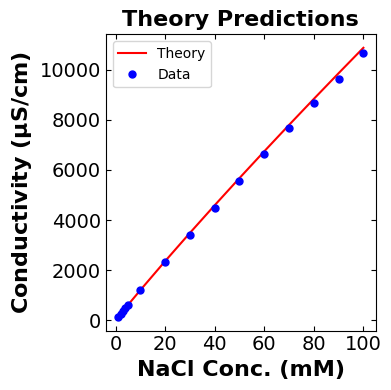

In [298]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(4,4))
plt.plot(salt_conc, all_cond_calc_con, "r-", label="Theory")
plt.plot(salt_conc, cond_exp, "b.", markersize=10, label="Data")
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.title("Theory Predictions", fontsize=16,fontweight='bold')
plt.legend()
plt.tight_layout()
# plt.savefig("msc_model_na.png")
plt.show()

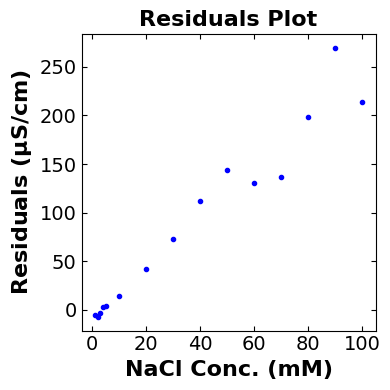

In [289]:
# residuals
e_nacl = [all_cond_calc_con[i] - cond_exp[i] for i in range(ndata)]

# making plot of residuals of calculated specific conductivity
fig = plt.figure(figsize=(4,4))
plt.plot(salt_conc, e_nacl, "b.")
plt.title("Residuals Plot", fontsize=16,fontweight='bold')
plt.xlabel("NaCl Conc. (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.tight_layout()
# plt.savefig("residuals_msc_model_na.png")
plt.show()